# CITES Wild-Sourced Mammal Trade - EDA Project

This notebook explores 10 years of international legal trade in wild-caught mammals, using data from CITES.

**Two parts**:
- **Part 1** - Explore, audit, and clean the raw data.
- **Part 2** - Visualize the main patterns and write a problem statement.

**Data source**: [CITES Trade Database](https://trade.cites.org/) with these filters:
- Trade type: Net imports
- Years: 2015–2024
- Class: Mammalia
- Source: W (wild-caught only)


# Part 1 - Explore and Clean the Data

## 1. Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## 2. Load the raw data

In [3]:
df = pd.read_csv('data_dashboard/net_imports_2026-07-11 19_22_comma_separated.csv')
df.head()


,App.,Taxon,Term,Unit,Country,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,I,Acinonyx jubatus,bodies,Number of specimens,BH,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN
1,I,Acinonyx jubatus,bodies,Number of specimens,CA,NaN,NaN,NaN,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN
2,I,Acinonyx jubatus,bodies,Number of specimens,CN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,1.0,NaN,NaN
3,I,Acinonyx jubatus,bodies,Number of specimens,DE,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
4,I,Acinonyx jubatus,bodies,Number of specimens,NZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN


## 3. How big is the dataset?

In [4]:
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.info()


Rows: 17,535
Columns: 16
<class 'pandas.DataFrame'>
RangeIndex: 17535 entries, 0 to 17534
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   App.     17535 non-null  str    
 1   Taxon    17535 non-null  str    
 2   Term     17535 non-null  str    
 3   Unit     8483 non-null   str    
 4   Country  17465 non-null  str    
 5   2016     4099 non-null   float64
 6   2017     3895 non-null   float64
 7   2018     3824 non-null   float64
 8   2019     4262 non-null   float64
 9   2020     3553 non-null   float64
 10  2021     3564 non-null   float64
 11  2022     3958 non-null   float64
 12  2023     3604 non-null   float64
 13  2024     3717 non-null   float64
 14  2025     222 non-null    float64
 15  2026     0 non-null      float64
dtypes: float64(11), str(5)
memory usage: 2.7 MB


**Note**: Years are stored as separate columns (wide format). We'll reshape this later.


## 4. Missing values

In [33]:
nulls = df.isnull().sum()
pct = (nulls / len(df) * 100).round(1)
pd.DataFrame({'nulls': nulls, 'pct_null': pct}).sort_values('nulls', ascending=False)


,nulls,pct_null
2026,17535,100.0
2025,17313,98.7
2020,13982,79.7
2021,13971,79.7
2023,13931,79.4
2024,13818,78.8
2018,13711,78.2
2017,13640,77.8
2022,13577,77.4
2016,13436,76.6


**What we see**:
- 2026 is fully empty. 2025 is almost empty. We'll drop them.
- `Unit` is blank in ~52% of rows. In CITES, blank means 'count of specimens'. We'll fill it.
- `Country` has 70 blank rows (0.4%). We'll drop them.


## 5. How many unique values per column?

In [34]:
for c in ['App.', 'Taxon', 'Term', 'Unit', 'Country']:
    print(f'{c:>8}: {df[c].nunique()} unique')


    App.: 4 unique
   Taxon: 730 unique
    Term: 57 unique
    Unit: 13 unique
 Country: 191 unique


## 6. CITES Appendix (protection level)

- **Appendix I** - species threatened with extinction
- **Appendix II** - trade must be controlled
- **Appendix III** - protected in specific countries
- **N** - not currently listed


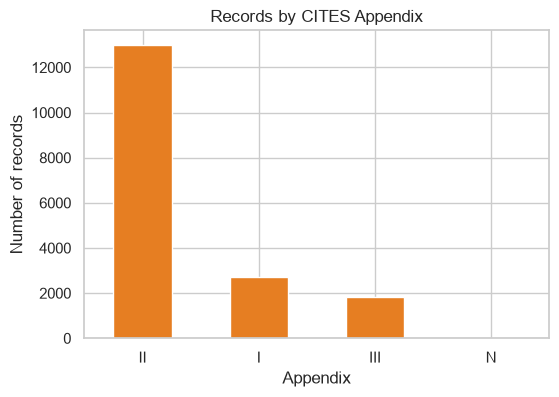

App.
II     12995
I       2707
III     1819
N         14
Name: count, dtype: int64

In [35]:
app_counts = df['App.'].value_counts()
app_counts.plot(kind='bar', color='#e67e22', figsize=(6, 4))
plt.title('Records by CITES Appendix')
plt.xlabel('Appendix')
plt.ylabel('Number of records')
plt.xticks(rotation=0)
plt.show()
app_counts


## 7. Which years have data?

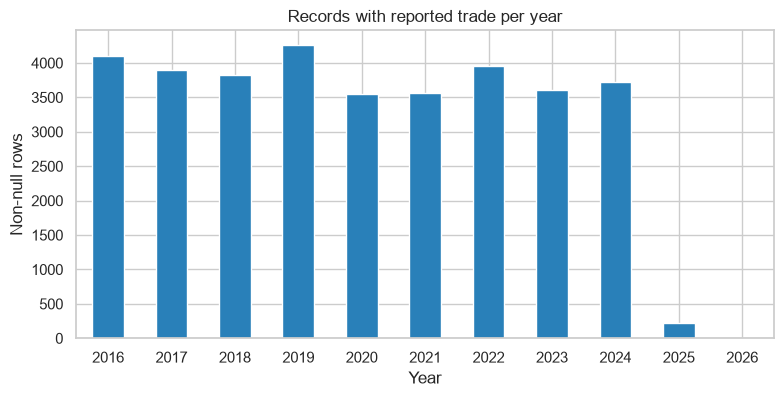

2016    4099
2017    3895
2018    3824
2019    4262
2020    3553
2021    3564
2022    3958
2023    3604
2024    3717
2025     222
2026       0
dtype: int64

In [36]:
year_cols = [c for c in df.columns if c.isdigit()]
yearly_records = pd.Series({y: df[y].notna().sum() for y in year_cols})

yearly_records.plot(kind='bar', color='#2980b9', figsize=(9, 4))
plt.title('Records with reported trade per year')
plt.xlabel('Year')
plt.ylabel('Non-null rows')
plt.xticks(rotation=0)
plt.show()
yearly_records


Confirmed: **2025 and 2026 are essentially empty**. We'll drop them.


## 8. Trade terms - what forms of trade appear?

In [37]:
df['Term'].value_counts().head(15)


Term
trophies                    3551
specimens                   2783
skins                       1656
live                        1333
skulls                      1302
bodies                       781
garments                     522
leather products (small)     518
skin pieces                  463
bones                        453
teeth                        439
tusks                        368
hair                         317
rug                          290
cloth                        201
Name: count, dtype: int64

## 9. Units of measurement

In [38]:
df['Unit'].value_counts(dropna=False).head(10)


Unit
NaN                    9052
Number of specimens    6749
kg                      675
g                       580
ml                      310
m2                       89
mg                       24
m                        22
l                        18
cm3                       6
Name: count, dtype: int64

Most rows have no unit (blank = specimen count). The rest are weights (kg, g) or volumes (ml). We'll fill the blanks with `'Number of specimens'`.


## 10. Clean the data

In [39]:
# Copy so we can rerun cells without reloading
df_clean = df.copy()

# Drop empty years
df_clean = df_clean.drop(columns=['2025', '2026'])

# Drop rows with missing Country
df_clean = df_clean.dropna(subset=['Country'])

# Fill missing Unit with the CITES-standard meaning
df_clean['Unit'] = df_clean['Unit'].fillna('Number of specimens')

print(f'After cleaning: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns')


After cleaning: 17,465 rows, 14 columns


## 11. Reshape to long format

Turn each year column into a row. This makes plotting and grouping much easier.


In [40]:
years = [c for c in df_clean.columns if c.isdigit()]

df_long = df_clean.melt(
    id_vars=['App.', 'Taxon', 'Term', 'Unit', 'Country'],
    value_vars=years,
    var_name='Year',
    value_name='Quantity'
)
df_long['Year'] = df_long['Year'].astype(int)

# Drop empty year-cells (no trade that year for that combination)
df_long = df_long.dropna(subset=['Quantity'])

print(f'Long-format dataset: {df_long.shape[0]:,} rows')
df_long.head()


Long-format dataset: 34,374 rows


,App.,Taxon,Term,Unit,Country,Year,Quantity
5,I,Acinonyx jubatus,bodies,Number of specimens,AR,2016,1.0
6,I,Acinonyx jubatus,bodies,Number of specimens,CA,2016,2.0
8,I,Acinonyx jubatus,bodies,Number of specimens,ES,2016,1.0
9,I,Acinonyx jubatus,bodies,Number of specimens,FR,2016,1.0
10,I,Acinonyx jubatus,bodies,Number of specimens,KP,2016,1.0


**Cleaning complete**. From this point on, we work with `df_long`.


# Part 2 - Visualize and Find Patterns

We answer four questions:
1. **When** - is trade going up, down, or steady?
2. **Where** - which countries are buying the most?
3. **What species** - which mammals are traded most?
4. **What form** - is it live animals, trophies, skins, ...?

**A note on the numbers**: We count **transactions** (how often trade happens), not summed quantities. Quantities are in mixed units, and one 2019 shipment of 360 million research 'specimens' would completely dominate any total. Counting transactions gives a cleaner picture. (We come back to that outlier in Section 17.)


## 12. When - Trade over time

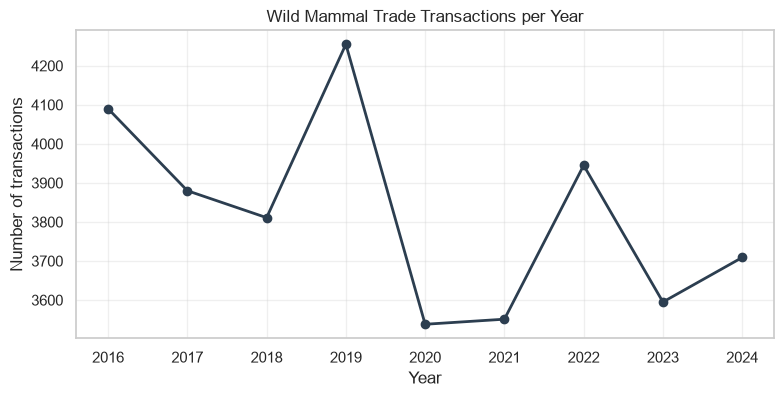

Year
2016    4090
2017    3880
2018    3811
2019    4255
2020    3538
2021    3551
2022    3945
2023    3595
2024    3709
dtype: int64

In [41]:
yearly = df_long.groupby('Year').size()

yearly.plot(kind='line', marker='o', figsize=(9, 4), color='#2c3e50', linewidth=2)
plt.title('Wild Mammal Trade Transactions per Year')
plt.xlabel('Year')
plt.ylabel('Number of transactions')
plt.grid(True, alpha=0.3)
plt.show()

yearly


**Finding**: Trade is steady at ~3,500–4,300 transactions/year. The small dip in 2020–2021 lines up with COVID-19. No overall decline.


## 13. Where - Top importing countries

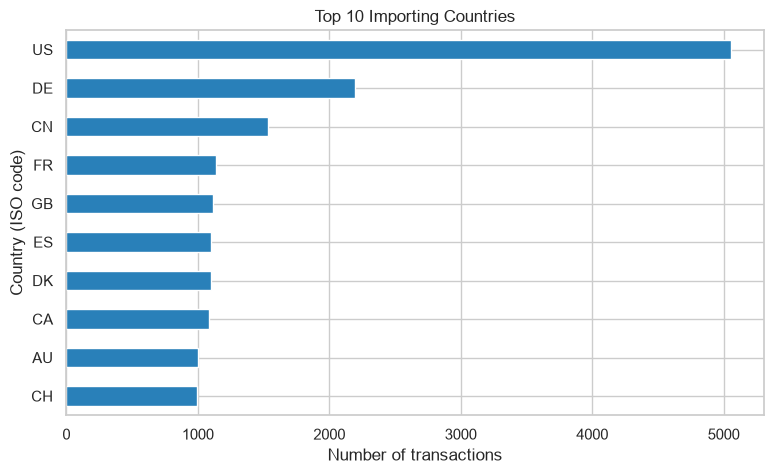

Country
US    5053
DE    2193
CN    1536
FR    1140
GB    1114
ES    1102
DK    1102
CA    1081
AU    1002
CH     997
Name: count, dtype: int64

In [42]:
top_importers = df_long['Country'].value_counts().head(10)

top_importers.plot(kind='barh', figsize=(9, 5), color='#2980b9')
plt.gca().invert_yaxis()
plt.title('Top 10 Importing Countries')
plt.xlabel('Number of transactions')
plt.ylabel('Country (ISO code)')
plt.show()

top_importers


**Country codes**: US = United States, DE = Germany, CN = China, FR = France, GB = United Kingdom, ES = Spain, DK = Denmark, CA = Canada, AU = Australia, CH = Switzerland.

**Finding**: The US alone accounts for over 5,000 transactions - more than 2× Germany. All top 10 importers are wealthy Western countries (plus China).


## 14. What species - Most traded mammals

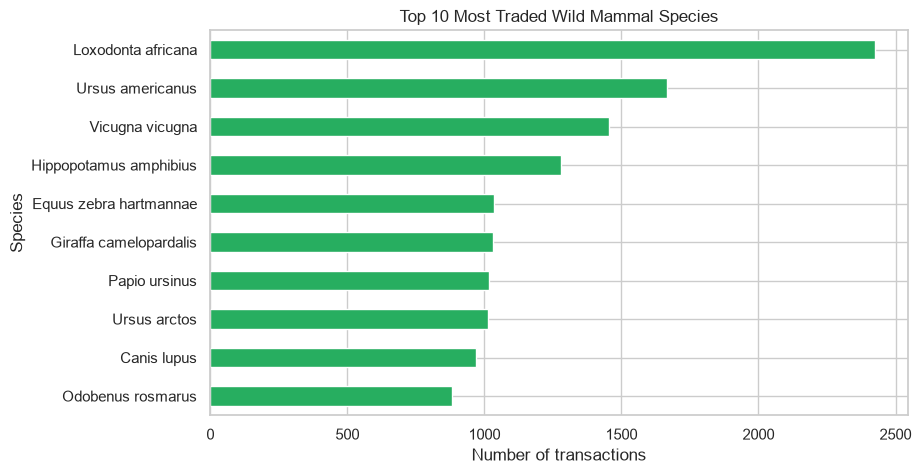

Taxon
Loxodonta africana        2424
Ursus americanus          1667
Vicugna vicugna           1455
Hippopotamus amphibius    1281
Equus zebra hartmannae    1034
Giraffa camelopardalis    1031
Papio ursinus             1016
Ursus arctos              1014
Canis lupus                968
Odobenus rosmarus          880
Name: count, dtype: int64

In [43]:
top_species = df_long['Taxon'].value_counts().head(10)

top_species.plot(kind='barh', figsize=(9, 5), color='#27ae60')
plt.gca().invert_yaxis()
plt.title('Top 10 Most Traded Wild Mammal Species')
plt.xlabel('Number of transactions')
plt.ylabel('Species')
plt.show()

top_species


**Common names**:
- *Loxodonta africana* → African elephant
- *Ursus americanus* → American black bear
- *Vicugna vicugna* → Vicuña (wool)
- *Hippopotamus amphibius* → Hippopotamus
- *Equus zebra hartmannae* → Hartmann's mountain zebra
- *Giraffa camelopardalis* → Giraffe
- *Papio ursinus* → Chacma baboon
- *Ursus arctos* → Brown bear
- *Canis lupus* → Gray wolf
- *Odobenus rosmarus* → Walrus

**Finding**: The top 10 are **African megafauna** and **large predators**. Iconic species - the same animals in wildlife documentaries.


## 15. What form - How the trade happens

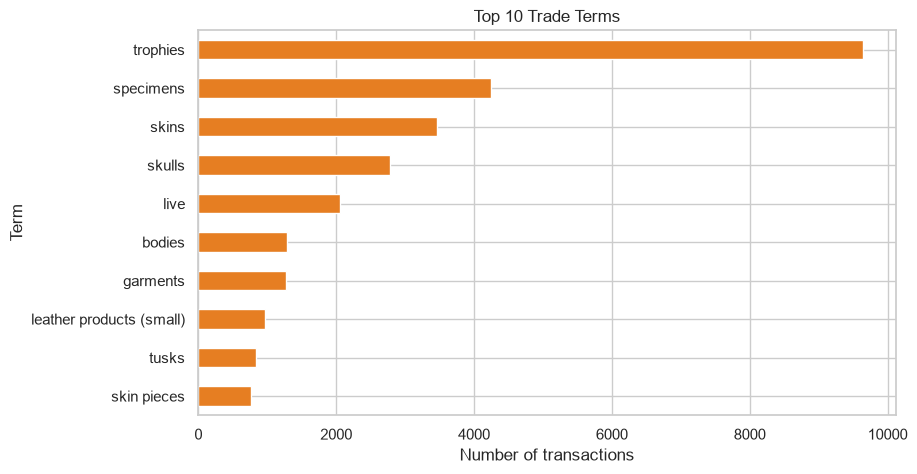

Term
trophies                    9638
specimens                   4252
skins                       3456
skulls                      2773
live                        2061
bodies                      1290
garments                    1274
leather products (small)     965
tusks                        842
skin pieces                  764
Name: count, dtype: int64

In [44]:
top_terms = df_long['Term'].value_counts().head(10)

top_terms.plot(kind='barh', figsize=(9, 5), color='#e67e22')
plt.gca().invert_yaxis()
plt.title('Top 10 Trade Terms')
plt.xlabel('Number of transactions')
plt.ylabel('Term')
plt.show()

top_terms


**Finding**: **Hunting trophies dominate** with 9,638 transactions - 28% of all wild-mammal trade. Combined with skulls, bodies, and skins, most trade fits a trophy-hunting pattern.


## 16. Bringing it together - Which species are trophy-hunted?

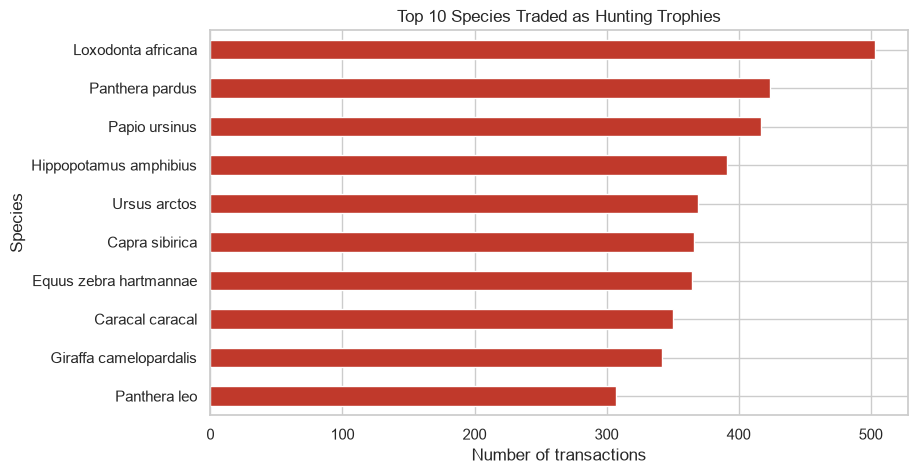

Taxon
Loxodonta africana        503
Panthera pardus           424
Papio ursinus             417
Hippopotamus amphibius    391
Ursus arctos              369
Capra sibirica            366
Equus zebra hartmannae    365
Caracal caracal           350
Giraffa camelopardalis    342
Panthera leo              307
Name: count, dtype: int64

In [45]:
trophies = df_long[df_long['Term'] == 'trophies']
top_trophy_species = trophies['Taxon'].value_counts().head(10)

top_trophy_species.plot(kind='barh', figsize=(9, 5), color='#c0392b')
plt.gca().invert_yaxis()
plt.title('Top 10 Species Traded as Hunting Trophies')
plt.xlabel('Number of transactions')
plt.ylabel('Species')
plt.show()

top_trophy_species


**Finding**: The trophy trade is exactly the African-megafauna and large-predator story from Section 14. The same iconic species that dominate the overall trade also dominate the trophy trade.


## 17. Notable finding - The 2019 outlier

In [46]:
outliers = df_long[df_long['Quantity'] > 1_000_000].sort_values('Quantity', ascending=False)
outliers[['App.', 'Taxon', 'Term', 'Country', 'Year', 'Quantity']].head()


,App.,Taxon,Term,Country,Year,Quantity
57338,II,Chlorocebus aethiops,specimens,EG,2019,240000000.0
57337,II,Chlorocebus aethiops,specimens,DZ,2019,80000000.0
57348,II,Chlorocebus aethiops,specimens,RU,2019,40000000.0
25442,II,Lama guanicoe,meat,CH,2017,3598560.0
122604,I,Balaenoptera physalus,meat,JP,2023,3000000.0


**Finding**: In 2019, Egypt (240M), Algeria (80M), and Russia (40M) reported importing 360 million *Chlorocebus aethiops* (African green monkey) 'specimens' - biological research samples, most likely tissue used in vaccine production.

**Data-quality lesson**: One reporting entry can dominate quantity totals. This is why we chose to count transactions instead of summing quantities.


# Problem Statement

---

> **Legal wild-mammal trade is steady, concentrated in wealthy Western demand, and dominated by hunting trophies of iconic species - elephants, leopards, and lions.**

---


## Summary of findings

| # | Question | Answer |
|---|----------|--------|
| 1 | Is trade growing or shrinking? | Steady (~3,500–4,300/year), small COVID dip |
| 2 | Who imports the most? | US (5,053), then Germany, China, France, UK |
| 3 | Which species dominate? | African elephant, black bear, vicuña, hippo, zebra, giraffe |
| 4 | What form of trade? | Hunting trophies (28% of all transactions) |
| 5 | Any anomaly? | 360M research samples of African green monkey in 2019 |
